In [ ]:
%pip install "pyrats[examples] @ git+https://github.com/Mishne-Lab/pyRATS"

In [ ]:
from matplotlib import pyplot as plt

from pyRATS import rats
import datasets, vis

import time

matplotlib.get_backend() =  module://matplotlib_inline.backend_inline


# Load data

In [2]:
X, labels, ddX = datasets.Datasets().swissrollwithholegrid(RES=50)

X.shape =  (2561, 3)


# Generate embeddings

In [3]:
model = rats.RATS(
    n_components=2,
    n_neighbors=28,
    min_cluster_size=5,
    tear=True,
)

start = time.time()

y = model.fit_transform(X=X)

end = time.time()
y, f'runtime: {end - start}'

(array([[ 0.25400146, -0.88942303],
        [ 0.23365535, -0.88985157],
        [ 0.21364089, -0.88964474],
        ...,
        [-0.21472263,  0.88419601],
        [-0.23469589,  0.88471377],
        [-0.25470945,  0.8851263 ]], shape=(2561, 2)),
 'runtime: 7.144066095352173')

# Tear coloring

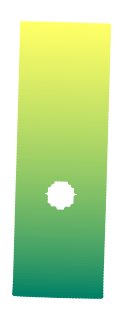

In [4]:
tear_color_eig_inds = [0, 1, 2] # interior has green color so assigned smallest value of i to g-channel
color_of_pts_on_tear = model.compute_color_of_pts_on_tear(
    y,
    tear_color_eig_inds, 
)
vis.Visualize().global_embedding(
    y, labels[:,0],
    color_of_pts_on_tear=color_of_pts_on_tear[:,tear_color_eig_inds] if color_of_pts_on_tear is not None else None,
    cmap0='summer',
    title='color='+str(tear_color_eig_inds),
    figsize=(3, 3)
)
plt.show()